# RAMIP × GWL: pixel KS path-independence test (GISS-E2-1-G sample)

**Same analysis as `ks_path_independence_maps.ipynb`, on raw RAMIP output.**
RAMIP swaps aerosol/precursor emissions to SSP1-2.6 levels while GHGs stay
SSP3-7.0 — so **ssp370 vs ssp370-126aer at the same GWL isolates the aerosol
pathway effect** at fixed global-mean warming: the cleanest possible
stress-test of GWL path-independence (idea #2 in our RAMIP×GWL notes).

**Sample:** GISS-E2-1-G, member r1i1p3f1 (only initial condition shared, only
emissions differ), daily `tas` 2015–2070 from the NASA NCCS datashare
(anonymous; CEDA's RAMIP archive is awaiting tape recovery after the Nov 2025
incident). Native 2°×2.5° grid, 365-day calendar → 20-yr GWL window gives
N = 7300 daily samples per pixel, matching the BCD-ME analysis.

**GWL windows** (20-yr rolling GMST anomaly vs 1850–1900, historical r1i1p3f1
baseline): computed in-notebook. ssp370-126aer reaches each GWL ~3–5 yr earlier
(aerosol cleanup unmasks warming) — the windows differ in years but match in GWL.

Same caveat as before: KS at N=7300 is overpowered; read the **spatial
pattern** and land-only fractions, not absolute p.

In [1]:
import os, glob, numpy as np, xarray as xr, regionmask
from scipy import stats as sstats
from matplotlib import pyplot as plt
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean

RAW    = '/burg-archive/home/mck2199/summer/summer_data/raw/ramip/GISS-E2-1-G/'
AUX    = '/burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/'
FIGS   = '/burg-archive/home/mck2199/summer/summer_data/figures/'
MODEL  = 'GISS-E2-1-G'
MEMBER = 'r1i1p3f1'
ANCHOR = 'ssp370'
OTHER  = 'ssp370-126aer'
GWLS   = [1.5, 2.0]
CACHE  = AUX + 'ks_pvals_ramip_giss_370_vs_126aer.nc'

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# GWL windows: 20-yr rolling GMST anomaly vs 1850-1900 (historical r1i1p3f1)
def gmst_ann(ds):
    w = np.cos(np.deg2rad(ds.lat))
    return ds.tas.weighted(w).mean(('lat', 'lon')).groupby('time.year').mean()

base = float(gmst_ann(xr.open_dataset(
    RAW + 'tas_Amon_GISS-E2-1-G_historical_r1i1p3f1_gn_185001-190012.nc')).mean())
tail = gmst_ann(xr.open_dataset(
    RAW + 'tas_Amon_GISS-E2-1-G_historical_r1i1p3f1_gn_200101-201412.nc'))

windows = {}   # (exp, gwl) -> (y0, y1)
for exp in [ANCHOR, OTHER]:
    g = xr.concat([tail, gmst_ann(xr.open_dataset(
        RAW + f'tas_Amon_{MODEL}_{exp}_{MEMBER}_gn_201501-207012.nc'))], dim='year') - base
    roll = g.rolling(year=20, center=True).mean()
    for gwl in GWLS:
        hit = roll.year.values[(roll >= gwl).values & np.isfinite(roll.values)]
        assert hit.size, f'{exp} never reaches GWL{gwl}'
        c = int(hit[0])
        windows[(exp, gwl)] = (c - 9, c + 10)
        print(f'{exp} GWL{gwl}: {c-9}-{c+10}')

ssp370 GWL1.5: 2024-2043
ssp370 GWL2.0: 2040-2059


ssp370-126aer GWL1.5: 2021-2040
ssp370-126aer GWL2.0: 2035-2054


In [3]:
# Daily tas for one experiment over a year window -> (lat, lon, time)
# Note: ssp370-126aer source file is missing Feb 2037 entirely (upstream gap on
# the NASA portal). Two-sample KS handles unequal N, so we keep separate sample
# dims and only warn on shortfall.
def daily(exp, y0, y1):
    files = sorted(glob.glob(RAW + f'tas_day_{MODEL}_{exp}_{MEMBER}_gn_*.nc'))
    ds = xr.open_mfdataset(files, combine='by_coords')
    da = ds.tas.sel(time=slice(f'{y0}-01-01', f'{y1}-12-31')).load()
    expect = (y1 - y0 + 1) * 365
    if da.time.size != expect:
        print(f'  note: {exp} {y0}-{y1} has {da.time.size} days (expected {expect})')
    return da

# Pixel-wise 2-sample KS p-value over daily samples (engine from diag_qdm.ipynb;
# separate core dims allow unequal sample counts)
def ks_pmap(da1, da2):
    def ks(x1, x2):
        return sstats.kstest(x1, x2).pvalue
    return xr.apply_ufunc(ks, da1.rename(time='t1'), da2.rename(time='t2'),
                          input_core_dims=[['t1'], ['t2']],
                          vectorize=True)

In [4]:
if os.path.exists(CACHE):
    print('loading cache', CACHE)
    pvals = xr.open_dataset(CACHE).pval
else:
    maps = []
    for gwl in GWLS:
        a0, a1 = windows[(ANCHOR, gwl)]
        b0, b1 = windows[(OTHER, gwl)]
        pv = ks_pmap(daily(ANCHOR, a0, a1), daily(OTHER, b0, b1))
        maps.append(pv.assign_coords(gwl=gwl))
        print(f'GWL{gwl} done')
    pvals = xr.concat(maps, dim='gwl').rename('pval')
    os.makedirs(AUX, exist_ok=True)
    pvals.to_dataset().to_netcdf(CACHE)
    print('saved', CACHE)

loading cache /burg-archive/home/mck2199/summer/summer_data/aux/diagnostics/ks_pvals_ramip_giss_370_vs_126aer.nc


In [5]:
# Land-only rejection fractions (grid includes ocean; report land only)
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
lm = ~np.isnan(land.mask(pvals.lon, pvals.lat))
for gwl in GWLS:
    p = pvals.sel(gwl=gwl).values[lm.values]
    print(f'GWL{gwl}: land frac p<0.05={np.mean(p < 0.05):.3f} '
          f'p<0.01={np.mean(p < 0.01):.3f} (n={p.size} land px)')

GWL1.5: land frac p<0.05=0.366 p<0.01=0.209 (n=4441 land px)
GWL2.0: land frac p<0.05=0.507 p<0.01=0.352 (n=4441 land px)


saved /burg-archive/home/mck2199/summer/summer_data/figures/ks_pvalue_maps_ramip_giss.png


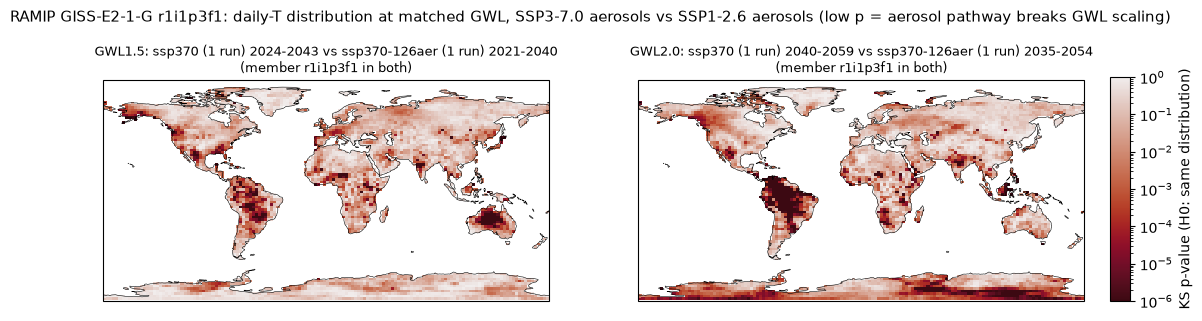

In [6]:
# Plot: one panel per GWL, log p, land only
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1.0)
cmap = cmocean.cm.amp_r
fig, axes = plt.subplots(1, len(GWLS), figsize=(13, 3.2),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, gwl in zip(np.atleast_1d(axes), GWLS):
    pv = pvals.sel(gwl=gwl).where(lm)
    im = pv.plot(ax=ax, transform=ccrs.PlateCarree(), norm=norm, cmap=cmap,
                 add_colorbar=False)
    a0, a1 = windows[(ANCHOR, gwl)]; b0, b1 = windows[(OTHER, gwl)]
    ax.coastlines(linewidth=0.4)
    ax.set_title(f'GWL{gwl}: {ANCHOR} (1 run) {a0}-{a1} vs {OTHER} (1 run) {b0}-{b1}\n'
                 f'(member {MEMBER} in both)', fontsize=9)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax, label='KS p-value (H0: same distribution)')
fig.suptitle(f'RAMIP {MODEL} {MEMBER}: daily-T distribution at matched GWL, '
             'SSP3-7.0 aerosols vs SSP1-2.6 aerosols (low p = aerosol pathway breaks GWL scaling)',
             y=1.06, fontsize=11)
os.makedirs(FIGS, exist_ok=True)
fig.savefig(FIGS + 'ks_pvalue_maps_ramip_giss.png', dpi=150, bbox_inches='tight')
print('saved', FIGS + 'ks_pvalue_maps_ramip_giss.png')